In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('./data/Exam Study Habits Survey (Responses).xlsx')
df.head()

,Timestamp,Major,Minor,Graduation Year,Where do you usually like to study?,Check the times that you would normally study in a given week [Monday],Check the times that you would normally study in a given week [Tuesday],Check the times that you would normally study in a given week [Wednesday],Check the times that you would normally study in a given week [Thursday],Check the times that you would normally study in a given week [Friday],Check the times that you would normally study in a given week [Saturday],Check the times that you would normally study in a given week [Sunday],How often in advance do you study for exams?,Any other information you would like to add?
0,2026-03-26 11:24:10.012,Information Sciences + Data Science,Computer Science; Economics,2028.0,"Grainger Library, CIF, Illini Union, Your Dorm...","4 pm - 8 pm, 8 pm - 12 am",8 pm - 12 am,NaN,"4 pm - 8 pm, 8 pm - 12 am","4 pm - 8 pm, 8 pm - 12 am","4 pm - 8 pm, 8 pm - 12 am","12 pm - 4 pm, 4 pm - 8 pm, 8 pm - 12 am",2-3 days,NaN
1,2026-03-26 13:34:45.013,Computer Science + Economics,NaN,2026.0,"Grainger Library, CIF, Main Library, Illini Un...","8 am - 12 pm, 12 pm - 4 pm, 4 pm - 8 pm, 8 pm ...","8 am - 12 pm, 12 pm - 4 pm, 4 pm - 8 pm, 8 pm ...","8 am - 12 pm, 12 pm - 4 pm, 4 pm - 8 pm, 8 pm ...","8 am - 12 pm, 12 pm - 4 pm, 4 pm - 8 pm, 8 pm ...","8 am - 12 pm, 12 pm - 4 pm, 4 pm - 8 pm","8 am - 12 pm, 12 pm - 4 pm, 4 pm - 8 pm","8 am - 12 pm, 12 pm - 4 pm, 4 pm - 8 pm",2-3 days,NaN
2,2026-03-29 15:03:13.215,IS + DS,Computer Science,2029.0,"Funk Library, Main Library, Illini Union, Your...","12 pm - 4 pm, 4 pm - 8 pm, 8 pm - 12 am","12 pm - 4 pm, 4 pm - 8 pm, 8 pm - 12 am","12 pm - 4 pm, 4 pm - 8 pm, 8 pm - 12 am","12 pm - 4 pm, 4 pm - 8 pm, 8 pm - 12 am","12 pm - 4 pm, 8 pm - 12 am",NaN,NaN,3-6 days,NaN
3,2026-03-29 16:56:07.549,Information Sciences & Data Science,Computer Science,2028.0,"Grainger Library, CIF","12 pm - 4 pm, 8 pm - 12 am",8 pm - 12 am,"12 pm - 4 pm, 8 pm - 12 am",8 pm - 12 am,"12 pm - 4 pm, 8 pm - 12 am",8 pm - 12 am,8 pm - 12 am,3-6 days,no
4,2026-03-29 19:01:49.101,NaN,NaN,NaN,"Funk Library, Your Dorm/Apartment",8 pm - 12 am,8 pm - 12 am,8 pm - 12 am,8 pm - 12 am,8 pm - 12 am,8 pm - 12 am,8 pm - 12 am,0-1 days,NaN


In [3]:
df['Major'].value_counts()

Major
Information Sciences + Data Science          4
IS + DS                                      3
Finance + DS                                 2
IS+DS                                        2
Finance + Data Science                       2
Computer Science + Economics                 1
Information Sciences & Data Science          1
Urban Planning                               1
Stats                                        1
Info sci                                     1
Is + Ds                                      1
Statistics                                   1
Data Science                                 1
Astronomy + Data Science                     1
Finance and Accountancy and Data Science     1
information science                          1
Information Science + Data Science           1
Computer Science                             1
Information Science Data Science             1
Stats and Econ                               1
Name: count, dtype: int64

In [4]:
def clean_major_column(df):
    """
    Clean up the 'Major' column according to specified rules.
    Some values will result in multiple columns (double majors).
    """
    # Create new columns for potential double majors
    df['Major_1'] = None
    df['Major_2'] = None
    
    # Define mapping for single major conversions
    single_major_mapping = {
        "IS + DS": "Information Sciences + Data Science",
        "IS+DS": "Information Sciences + Data Science",
        "Information Sciences & Data Science": "Information Sciences + Data Science",
        "Is + Ds": "Information Sciences + Data Science",
        "Data Science": "Information Sciences + Data Science",
        "Information Science + Data Science": "Information Sciences + Data Science",
        "Information Science Data Science": "Information Sciences + Data Science",
        "Stats": "Statistics",
        "Info Sci": "Information Sciences",
        "information science": "Information Sciences",
    }
    
    # Process each row
    for idx, value in df['Major'].items():
        if pd.isna(value):
            continue
            
        value_stripped = value.strip()
        
        # Check for double majors first
        if value_stripped == "Stats and Econ":
            df.at[idx, 'Major_1'] = "Statistics"
            df.at[idx, 'Major_2'] = "Economics"
        elif value_stripped == "Finance and Accountancy and Data Science":
            df.at[idx, 'Major_1'] = "Finance + Data Science"
            df.at[idx, 'Major_2'] = "Accountancy"
        # Check for single major mappings
        elif value_stripped in single_major_mapping:
            df.at[idx, 'Major_1'] = single_major_mapping[value_stripped]
        else:
            # Keep original value if no mapping found
            df.at[idx, 'Major_1'] = value_stripped
    
    return df

In [5]:
df = clean_major_column(df)

In [6]:
# Convert the comma-separated string into a list of strings
df['Where do you usually like to study?'] = df['Where do you usually like to study?'].str.split(', ')

In [7]:
# Define iSchool variations mapping
ischool_variations = ['Ischool', 'ischool', 'ISchool', 'I school']

# Function to clean up iSchool variations in a list
def clean_ischool(locations):
    if isinstance(locations, list):
        return ['iSchool' if loc.strip() in ischool_variations else loc.strip() for loc in locations]
    return locations

# Apply the cleaning function
df['Where do you usually like to study?'] = df['Where do you usually like to study?'].apply(clean_ischool)

In [8]:
# Explode the list so each location gets its own row, then count frequencies
location_counts = df['Where do you usually like to study?'].explode().value_counts()
print(location_counts)

Where do you usually like to study?
Your Dorm/Apartment         19
Grainger Library            15
CIF                         14
Illini Union                13
Main Library                10
Funk Library                10
BIF                          7
Siebel Center for Design     7
Siebel Center for CS         5
iSchool                      4
Name: count, dtype: int64


In [9]:
df.head()

,Timestamp,Major,Minor,Graduation Year,Where do you usually like to study?,Check the times that you would normally study in a given week [Monday],Check the times that you would normally study in a given week [Tuesday],Check the times that you would normally study in a given week [Wednesday],Check the times that you would normally study in a given week [Thursday],Check the times that you would normally study in a given week [Friday],Check the times that you would normally study in a given week [Saturday],Check the times that you would normally study in a given week [Sunday],How often in advance do you study for exams?,Any other information you would like to add?,Major_1,Major_2
0,2026-03-26 11:24:10.012,Information Sciences + Data Science,Computer Science; Economics,2028.0,"[Grainger Library, CIF, Illini Union, Your Dor...","4 pm - 8 pm, 8 pm - 12 am",8 pm - 12 am,NaN,"4 pm - 8 pm, 8 pm - 12 am","4 pm - 8 pm, 8 pm - 12 am","4 pm - 8 pm, 8 pm - 12 am","12 pm - 4 pm, 4 pm - 8 pm, 8 pm - 12 am",2-3 days,NaN,Information Sciences + Data Science,None
1,2026-03-26 13:34:45.013,Computer Science + Economics,NaN,2026.0,"[Grainger Library, CIF, Main Library, Illini U...","8 am - 12 pm, 12 pm - 4 pm, 4 pm - 8 pm, 8 pm ...","8 am - 12 pm, 12 pm - 4 pm, 4 pm - 8 pm, 8 pm ...","8 am - 12 pm, 12 pm - 4 pm, 4 pm - 8 pm, 8 pm ...","8 am - 12 pm, 12 pm - 4 pm, 4 pm - 8 pm, 8 pm ...","8 am - 12 pm, 12 pm - 4 pm, 4 pm - 8 pm","8 am - 12 pm, 12 pm - 4 pm, 4 pm - 8 pm","8 am - 12 pm, 12 pm - 4 pm, 4 pm - 8 pm",2-3 days,NaN,Computer Science + Economics,None
2,2026-03-29 15:03:13.215,IS + DS,Computer Science,2029.0,"[Funk Library, Main Library, Illini Union, You...","12 pm - 4 pm, 4 pm - 8 pm, 8 pm - 12 am","12 pm - 4 pm, 4 pm - 8 pm, 8 pm - 12 am","12 pm - 4 pm, 4 pm - 8 pm, 8 pm - 12 am","12 pm - 4 pm, 4 pm - 8 pm, 8 pm - 12 am","12 pm - 4 pm, 8 pm - 12 am",NaN,NaN,3-6 days,NaN,Information Sciences + Data Science,None
3,2026-03-29 16:56:07.549,Information Sciences & Data Science,Computer Science,2028.0,"[Grainger Library, CIF]","12 pm - 4 pm, 8 pm - 12 am",8 pm - 12 am,"12 pm - 4 pm, 8 pm - 12 am",8 pm - 12 am,"12 pm - 4 pm, 8 pm - 12 am",8 pm - 12 am,8 pm - 12 am,3-6 days,no,Information Sciences + Data Science,None
4,2026-03-29 19:01:49.101,NaN,NaN,NaN,"[Funk Library, Your Dorm/Apartment]",8 pm - 12 am,8 pm - 12 am,8 pm - 12 am,8 pm - 12 am,8 pm - 12 am,8 pm - 12 am,8 pm - 12 am,0-1 days,NaN,None,None


## Study Time Distribution by Day of Week

In [10]:
# Find all columns that contain study time selections
time_cols = [col for col in df.columns if "Check the times" in col and "study" in col.lower()]

print("Found time columns:")
for col in time_cols:
    print(f"  - {col}")

Found time columns:
  - Check the times that you would normally study in a given week [Monday]
  - Check the times that you would normally study in a given week [Tuesday]
  - Check the times that you would normally study in a given week [Wednesday]
  - Check the times that you would normally study in a given week [Thursday]
  - Check the times that you would normally study in a given week [Friday]
  - Check the times that you would normally study in a given week [Saturday]
  - Check the times that you would normally study in a given week [Sunday]


In [11]:
# Dictionary to store the distribution for each day
day_distributions = {}

for col in time_cols:
    # Extract the day name from the column (e.g., "Monday")
    day = col.split(";")[-1].strip()
    
    # Get the value counts (distribution) for this day
    # Handle NaN values and split comma-separated strings
    times_series = df[col].dropna().str.split(', ').explode().str.strip()
    distribution = times_series.value_counts()
    
    day_distributions[day] = distribution

In [12]:
# Display the distributions for each day
for day, dist in day_distributions.items():
    print(f"\n=== {day} ===")
    print(dist)


=== Check the times that you would normally study in a given week [Monday] ===
Check the times that you would normally study in a given week [Monday]
8 pm - 12 am    21
4 pm - 8 pm     19
12 pm - 4 pm    11
8 am - 12 pm     7
12 am - 8am      3
Name: count, dtype: int64

=== Check the times that you would normally study in a given week [Tuesday] ===
Check the times that you would normally study in a given week [Tuesday]
8 pm - 12 am    22
4 pm - 8 pm     17
12 pm - 4 pm    10
8 am - 12 pm     6
12 am - 8am      3
Name: count, dtype: int64

=== Check the times that you would normally study in a given week [Wednesday] ===
Check the times that you would normally study in a given week [Wednesday]
8 pm - 12 am    22
4 pm - 8 pm     19
12 pm - 4 pm    11
8 am - 12 pm     6
12 am - 8am      4
Name: count, dtype: int64

=== Check the times that you would normally study in a given week [Thursday] ===
Check the times that you would normally study in a given week [Thursday]
8 pm - 12 am    23
4 

In [13]:
def extract_day_name(col):
    # Column format: "Check the times that you would normally study in a given week [Monday]"
    # Extract content between [ and ]
    if '[' in col and ']' in col:
        return col.split('[')[1].split(']')[0]
    # Fallback: split by ; and take last part
    return col.split(";")[-1].strip()

In [14]:
# Create a summary DataFrame showing counts for each time slot across all days
all_times = []

for col in time_cols:
    day = extract_day_name(col)
    # Handle NaN values and split comma-separated strings
    times_series = df[col].dropna().str.split(', ').explode().str.strip()
    times = times_series.value_counts().reset_index()
    times.columns = ['Time Slot', 'Count']
    times['Day'] = day
    all_times.append(times)

# Combine all days into one DataFrame
summary_df = pd.concat(all_times, ignore_index=True)

print("=== Summary DataFrame ===")
print(summary_df.head(20))

=== Summary DataFrame ===
       Time Slot  Count        Day
0   8 pm - 12 am     21     Monday
1    4 pm - 8 pm     19     Monday
2   12 pm - 4 pm     11     Monday
3   8 am - 12 pm      7     Monday
4    12 am - 8am      3     Monday
5   8 pm - 12 am     22    Tuesday
6    4 pm - 8 pm     17    Tuesday
7   12 pm - 4 pm     10    Tuesday
8   8 am - 12 pm      6    Tuesday
9    12 am - 8am      3    Tuesday
10  8 pm - 12 am     22  Wednesday
11   4 pm - 8 pm     19  Wednesday
12  12 pm - 4 pm     11  Wednesday
13  8 am - 12 pm      6  Wednesday
14   12 am - 8am      4  Wednesday
15  8 pm - 12 am     23   Thursday
16   4 pm - 8 pm     16   Thursday
17  12 pm - 4 pm     10   Thursday
18  8 am - 12 pm      6   Thursday
19   12 am - 8am      4   Thursday


In [15]:
# Debug: Check data types
print("\n=== Summary DataFrame dtypes ===")
print(summary_df.dtypes)


=== Summary DataFrame dtypes ===
Time Slot    object
Count         int64
Day          object
dtype: object


In [16]:
# Pivot to get days as columns
pivot_df = summary_df.pivot_table(index='Time Slot', columns='Day', values='Count', aggfunc='sum', fill_value=0)

# Ensure all values are numeric
pivot_df = pivot_df.astype(int)

# Sort by total count across all days for better visualization
pivot_df['Total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values('Total', ascending=False)
pivot_df = pivot_df.drop(columns='Total')

print("\n=== Combined View (Time Slots by Day) ===")
print(pivot_df)
print("\n=== Pivot DataFrame dtypes ===")
print(pivot_df.dtypes)



=== Combined View (Time Slots by Day) ===
Day           Friday  Monday  Saturday  Sunday  Thursday  Tuesday  Wednesday
Time Slot                                                                   
8 pm - 12 am      13      21        13      20        23       22         22
4 pm - 8 pm       11      19        13      17        16       17         19
12 pm - 4 pm      14      11        13      16        10       10         11
8 am - 12 pm       5       7         5       6         6        6          6
12 am - 8am        2       3         2       2         4        3          4

=== Pivot DataFrame dtypes ===
Day
Friday       int64
Monday       int64
Saturday     int64
Sunday       int64
Thursday     int64
Tuesday      int64
Wednesday    int64
dtype: object


In [17]:
# Visualize the distributions
# Reorder days for consistent plotting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
available_days = [d for d in day_order if d in pivot_df.columns]
pivot_df = pivot_df[available_days]

print("\n=== Final Pivot DataFrame ===")
print(pivot_df)
print("\n=== Final Pivot DataFrame dtypes ===")
print(pivot_df.dtypes)


=== Final Pivot DataFrame ===
Day           Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
Time Slot                                                                   
8 pm - 12 am      21       22         22        23      13        13      20
4 pm - 8 pm       19       17         19        16      11        13      17
12 pm - 4 pm      11       10         11        10      14        13      16
8 am - 12 pm       7        6          6         6       5         5       6
12 am - 8am        3        3          4         4       2         2       2

=== Final Pivot DataFrame dtypes ===
Day
Monday       int64
Tuesday      int64
Wednesday    int64
Thursday     int64
Friday       int64
Saturday     int64
Sunday       int64
dtype: object


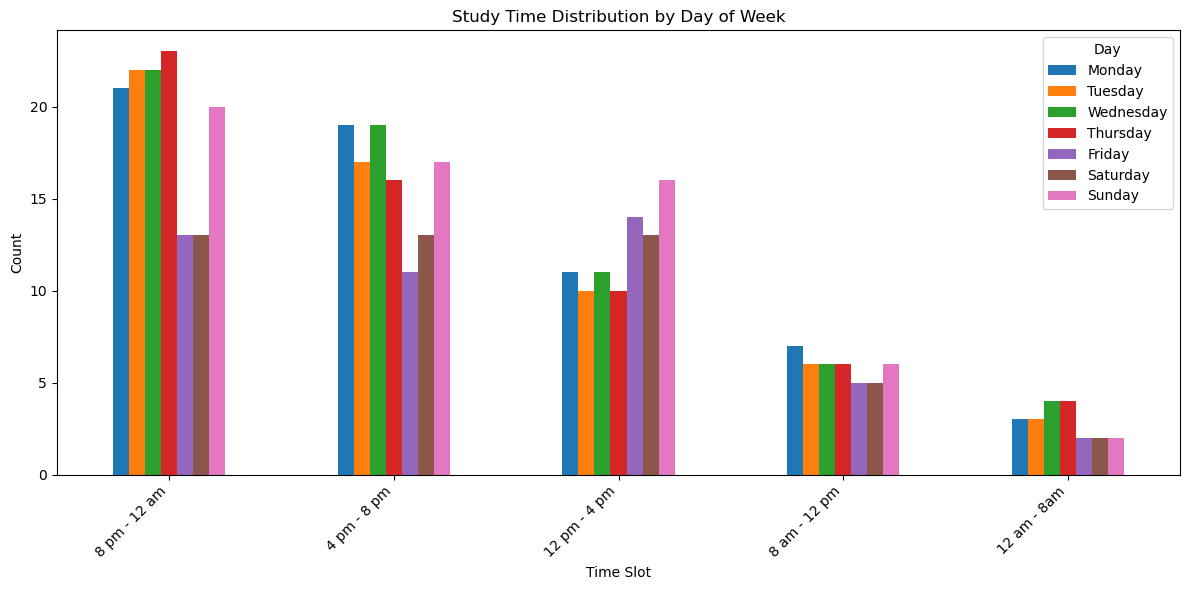

In [18]:


# Plot as a bar chart
ax = pivot_df.plot(kind='bar', figsize=(12, 6))
plt.title('Study Time Distribution by Day of Week')
plt.xlabel('Time Slot')
plt.ylabel('Count')
plt.legend(title='Day')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# How Often In Advance People Study

In [19]:
# Get value counts
value_counts = df['How often in advance do you study for exams?'].value_counts()

# Map categories to estimated days (using midpoints for ranges)
days_mapping = {
    '0-1 days': 0.5,   # midpoint of 0-1
    '2-3 days': 2.5,   # midpoint of 2-3
    '3-6 days': 4.5,   # midpoint of 3-6
    '7+ days': 8       # conservative estimate for 7+ (could also use 7 or higher)
}

# Calculate expected value
total_responses = value_counts.sum()
expected_value = sum(days_mapping[cat] * count for cat, count in value_counts.items()) / total_responses

print(f"Category breakdown:")
for cat, count in value_counts.items():
    print(f"  {cat}: {count} responses → {days_mapping[cat]} days")

print(f"\nTotal responses: {total_responses}")
print(f"Expected value: {expected_value:.2f} days in advance")
print("We will use 3 days")

Category breakdown:
  2-3 days: 15 responses → 2.5 days
  3-6 days: 9 responses → 4.5 days
  0-1 days: 3 responses → 0.5 days
  7+ days: 2 responses → 8 days

Total responses: 29
Expected value: 3.29 days in advance
We will use 3 days


In [ ]:
# Tuning parameters for each location's peaks (on a normal day) and distributions:
grainger_max = 0.8
funk_max = 0.75
union_max_lunch = 0.75
union_max_dinner = 0.65
main_lib_max = 0.75

In [9]:
import pandas as pd
import numpy as np

# --- 1. Helper to generate a smoothed hour-by-hour curve ---
def generate_daily_curve(peak_hour, width=3.0, max_val=1.0, is_weekend=False):
    """Creates a bell curve of occupancy based on the peak hour."""
    hours = np.arange(24)
    # Gaussian distribution equation
    curve = np.exp(-0.5 * ((hours - peak_hour) / width)**2)
    
    # Scale down maximum occupancy on weekends
    if is_weekend:
        max_val *= 0.6
        
    return curve * max_val

# --- 2. Build the Base Google Curves for the Week ---
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
base_data = []

for day in days:
    is_wkd = day in ['Saturday', 'Sunday']
    
    # Grainger: Peak 3 PM (15), busiest Wed-Fri
    g_max = grainger_max if day in ['Wednesday', 'Thursday', 'Friday'] else 0.85*grainger_max
    grainger = generate_daily_curve(15, width=3.5, max_val=g_max, is_weekend=is_wkd)
    
    # Funk: Variable peaks
    if day in ['Monday', 'Wednesday']: f_peak = 13
    elif day in ['Tuesday', "Thursday"]: f_peak = 14
    elif day == 'Friday': f_peak = 12
    else: f_peak = 14
    f_max = funk_max if not is_wkd else 0.5
    funk = generate_daily_curve(f_peak, width=3.0, max_val=f_max, is_weekend=is_wkd)
    
    # Main Library: Peak 2 PM (14)
    m_max = main_lib_max if not is_wkd else 0.5*main_lib_max 
    main_lib = generate_daily_curve(14, width=3.5, max_val=m_max, is_weekend=is_wkd)
    
    # Illini Union: Bi-modal (Lunch and Dinner peaks)
    u_lunch = generate_daily_curve(12, width=2.0, max_val=union_max_lunch, is_weekend=is_wkd)
    u_dinner = generate_daily_curve(18, width=3.0, max_val=union_max_dinner, is_weekend=is_wkd)
    union = np.maximum(u_lunch, u_dinner) # Takes the highest point of both curves
    
    for h in range(24):
        base_data.append({
            'Day': day, 'Hour': h, 
            'Grainger Library': grainger[h], 
            'Funk Library': funk[h], 
            'Main Library': main_lib[h], 
            'Illini Union': union[h]
        })

df_base = pd.DataFrame(base_data)

# --- 3. The Sister Mapping & Survey Scaling ---
# Multiply by the survey ratios (e.g. CIF had 14 votes, Grainger had 15)
df_base['CIF'] = df_base['Grainger Library'] * (14/15)
df_base['BIF'] = df_base['Main Library'] * (7/10)
df_base['Siebel Center for CS'] = df_base['Grainger Library'] * (7/15)
df_base['Siebel Center for Design'] = df_base['Funk Library'] * (7/10)

# Reshape data for ML
df_melted = df_base.melt(id_vars=['Day', 'Hour'], var_name='Building', value_name='Base_Popularity')

# --- 4. Advanced Building Hours Mask ---

# We map each building to a dictionary of Days, containing a list of integer hours (0-23) it is open.
# Note: 8:30 AM is rounded to 8 (8:00 AM - 8:59 AM hour block).
# Closes at 11 PM (23:00) means the 22nd hour (10:00 PM - 10:59 PM) is the last fully open block. 
# Midnight (12 AM) is effectively the end of the 23rd hour.

schedule = {
    'Grainger Library': {
        'Monday': list(range(0, 24)), 
        'Tuesday': list(range(0, 24)), 
        'Wednesday': list(range(0, 24)), 
        'Thursday': list(range(0, 24)), 
        'Friday': list(range(0, 24)), 
        'Saturday': list(range(10, 24)), 
        'Sunday': list(range(10, 24))
    },
    'Funk Library': {
        # 1A and 2A spillovers handled at 0 and 1 of the NEXT day
        'Monday': [0, 1] + list(range(8, 24)),      # Sun night spillover + 8:30A-Midnight
        'Tuesday': [0, 1] + list(range(8, 24)),     # Mon night spillover + 8:30A-Midnight
        'Wednesday': [0, 1] + list(range(8, 24)),   # Tue night spillover + 8:30A-Midnight
        'Thursday': [0, 1] + list(range(8, 24)),    # Wed night spillover + 8:30A-Midnight
        'Friday': [0, 1] + list(range(8, 18)),      # Thu night spillover + 8:30A-6P
        'Saturday': list(range(10, 21)),            # 10A-9P
        'Sunday': list(range(13, 24))               # 1P-Midnight (spills into Monday)
    },
    'Main Library': {
        'Monday': list(range(8, 23)),               # 8:30A-11P
        'Tuesday': list(range(8, 23)),
        'Wednesday': list(range(8, 23)),
        'Thursday': list(range(8, 23)),
        'Friday': list(range(8, 18)),               # 8:30A-6P
        'Saturday': list(range(13, 17)),            # 1P-5P
        'Sunday': list(range(13, 23))               # 1P-11P
    },
    'Illini Union': {
        day: list(range(7, 23)) for day in days     # 7A-11P Every Day
    },
    'CIF': {
        'Monday': list(range(7, 23)),
        'Tuesday': list(range(7, 23)),
        'Wednesday': list(range(7, 23)),
        'Thursday': list(range(7, 23)),
        'Friday': list(range(7, 21)),               # 7A-9P
        'Saturday': list(range(9, 21)),             # 9A-9P
        'Sunday': list(range(12, 23))               # 12P-11P
    },
    'BIF': {
        'Monday': list(range(6, 24)),               # 6A-12A
        'Tuesday': list(range(6, 24)),
        'Wednesday': list(range(6, 24)),
        'Thursday': list(range(6, 24)),
        'Friday': list(range(6, 20)),               # 6A-8P
        'Saturday': list(range(6, 20)),             # 6A-8P
        'Sunday': list(range(10, 24))               # Assuming 10A-12A (Midnight)
    },
    'Siebel Center for CS': {
        day: list(range(7, 22)) for day in days     # 7A-9:30P (Using 21 as last full hour)
    },
    'Siebel Center for Design': {
        day: list(range(7, 24)) for day in days     # 7A-12A Every Day
    }
}

def apply_hours_mask(row):
    building = row['Building']
    day = row['Day']
    hour = row['Hour']
    base_pop = row['Base_Popularity']
    
    open_hours = schedule[building][day]
    
    if hour in open_hours:
        return base_pop
    else:
        # --- Handle After-Hours Edge Cases ---
        
        # Siebel CS Swipe Access: Instead of dropping to 0, it drops to 15% of its normal 
        # popularity curve (simulating majors swiping in to study late).
        if building == 'Siebel Center for CS':
            return base_pop * 0.15 
            
        # All other buildings are strictly locked
        return 0.0

df_melted['Base_Popularity'] = df_melted.apply(apply_hours_mask, axis=1)

print(df_melted.head(10))

      Day  Hour          Building  Base_Popularity
0  Monday     0  Grainger Library         0.000070
1  Monday     1  Grainger Library         0.000228
2  Monday     2  Grainger Library         0.000687
3  Monday     3  Grainger Library         0.001905
4  Monday     4  Grainger Library         0.004871
5  Monday     5  Grainger Library         0.011478
6  Monday     6  Grainger Library         0.024927
7  Monday     7  Grainger Library         0.049891
8  Monday     8  Grainger Library         0.092028
9  Monday     9  Grainger Library         0.156445


In [10]:
df_melted.to_csv('./data/base_popularity_distributions.csv', index=False)

In [44]:
# Calculate study pressure
import math

def get_study_pressure_multiplier(exams_list):
    """
    exams_list: A list of integers representing 'days away' for each exam.
    e.g., [1, 3] means one exam tomorrow, one exam in 3 days.
    (Remember to pass CBTF exams based only on their final day).
    """
    
    # 1. Calculate Raw Score
    raw_score = 0
    for days_away in exams_list:
        if 0 <= days_away <= 3:
            raw_score += (4 - days_away) 
            
    # 2. Tuning Parameters
    THRESHOLD = 4.0      # E.g., 1 exam today (4pts) = no effect. Must exceed 4.
    MAX_BOOST = 0.60     # The multiplier approaches, but never exceeds, 1.60x
    GROWTH_RATE = 0.25   # Controls how fast the curve hits the ceiling
    
    # 3. Apply Threshold and Squash
    if raw_score <= THRESHOLD:
        return 1.0  # Normal baseline demand
    else:
        # Exponential curve that flatlines at the upper bound
        boost = MAX_BOOST * (1 - math.exp(-GROWTH_RATE * (raw_score - THRESHOLD)))
        return 1.0 + boost

# --- Example Scenarios ---
# Scenario A: 1 exam tomorrow (3 pts).
print(get_study_pressure_multiplier([1])) 
# Output: 1.0 (Doesn't beat the threshold)

# Scenario B: Midterm season. 1 exam tmrw, 1 in 2 days, 1 in 3 days (3+2+1 = 6 pts)
print(get_study_pressure_multiplier([1, 2, 3])) 
# Output: ~1.23 (Demand increases by 23%)

# Scenario C: Hell week. 3 exams tomorrow, 2 the next day (3+3+3+2+2 = 13 pts)
print(get_study_pressure_multiplier([1, 1, 1, 2, 2])) 
# Output: ~1.53 (Demand increases by 53%, safely below the 1.60x cap)

1.0
1.2360816041724199
1.5367604652628812


In [45]:
pressure_index = get_study_pressure_multiplier([1, 2, 3, 4])

# Apply the multiplier, but cap the building at 1.0 (100% capacity)
df_melted['Current_Demand'] = np.minimum(1.0, df_melted['Base_Popularity'] * pressure_index)

# Calculate Spillover for the Location Allocator
df_melted['Spillover'] = np.maximum(0.0, (df_melted['Base_Popularity'] * pressure_index) - 1.0)

In [46]:
pressure_index

1.2360816041724199

In [51]:
df_melted.sample(n=10)

,Day,Hour,Building,Base_Popularity,Current_Demand,Spillover
338,Monday,2,Main Library,0.000000,0.000000,0.000000
1146,Saturday,18,Siebel Center for CS,0.161538,0.199675,0.000000
1182,Monday,6,Siebel Center for Design,0.000000,0.000000,0.000000
345,Monday,9,Main Library,0.324403,0.400989,0.000000
439,Friday,7,Main Library,0.000000,0.000000,0.000000
1147,Saturday,19,Siebel Center for CS,0.152809,0.188884,0.000000
829,Sunday,13,CIF,0.363868,0.449771,0.000000
229,Wednesday,13,Funk Library,0.850000,1.000000,0.050669
201,Tuesday,9,Funk Library,0.211949,0.261987,0.000000
397,Wednesday,13,Main Library,0.864005,1.000000,0.067981


In [35]:
df_melted[(df_melted['Day'] == 'Tuesday') & (df_melted['Hour'] >= 10) & (df_melted['Hour'] <= 20)]

,Day,Hour,Building,Base_Popularity,Current_Demand,Spillover
34,Tuesday,10,Grainger Library,0.306381,0.428933,0.000000
35,Tuesday,11,Grainger Library,0.442383,0.619336,0.000000
36,Tuesday,12,Grainger Library,0.588684,0.824157,0.000000
37,Tuesday,13,Grainger Library,0.721961,1.000000,0.010745
38,Tuesday,14,Grainger Library,0.816005,1.000000,0.142406
...,...,...,...,...,...,...
1216,Tuesday,16,Siebel Center for Design,0.504465,0.706250,0.000000
1217,Tuesday,17,Siebel Center for Design,0.382114,0.534960,0.000000
1218,Tuesday,18,Siebel Center for Design,0.259001,0.362601,0.000000
1219,Tuesday,19,Siebel Center for Design,0.157092,0.219929,0.000000


In [52]:
df_melted.to_csv('./data/test_demand_distributions.csv', index=False)